#  Resume–Job Matching
## Recruitment NLP Lab — Step 6: Matching Resumes to Job Descriptions

This notebook matches resumes to the most relevant job descriptions
using **cosine similarity** on TF-IDF vectors.

**What cosine similarity does:**
- Measures the angle between two text vectors
- Score of 1.0 = identical content, 0.0 = completely unrelated
- Higher score = better resume–job match

**Confirmed from previous notebooks:**
- 466 resumes across 4 categories -> `resumes_cleaned.csv`
- 50,000 job descriptions -> `jobs_cleaned.csv`
- TF-IDF matrices saved -> `resume_tfidf_matrix.npz`, `job_tfidf_matrix.npz`
- Category classifier accuracy: 89.36%
- Experience classifier accuracy: 65.96%
- Resume experience levels -> `resume_with_levels.csv`

**Goals:**
1. For each job description, find the top-N most similar resumes
2. Evaluate match quality using similarity score distribution
3. Filter matches by predicted category and experience level
4. Visualize matching results
5. Save match results for the report

##  1. Install & Import Libraries

In [1]:
!py -3.11 -m pip install scikit-learn pandas numpy matplotlib seaborn tensorflow


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: C:\Users\Dell\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import scipy.sparse as sp

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow import keras

os.makedirs("../results/plots",   exist_ok=True)
os.makedirs("../results/metrics", exist_ok=True)

print("   All libraries imported!")
print(f"   TensorFlow : {tf.__version__}")

   All libraries imported!
   TensorFlow : 2.20.0


##  2. Load All Saved Data

Loading TF-IDF matrices, cleaned datasets, and encoders saved from
previous notebooks. No reprocessing needed.

In [3]:
# Load cleaned datasets
resumes = pd.read_csv("../data/processed/resumes_cleaned.csv")
jobs    = pd.read_csv("../data/processed/jobs_cleaned.csv")

# Load resume experience levels
resume_levels = pd.read_csv("../data/processed/resume_with_levels.csv")

# Merge experience levels into resumes
resumes = resumes.merge(
    resume_levels[['ID', 'experience_level', 'years_extracted']],
    on='ID', how='left'
)

print(f"   Resumes loaded     -> {resumes.shape[0]} rows")
print(f"   Jobs loaded        -> {jobs.shape[0]:,} rows")
print(f"\nResume columns   : {resumes.columns.tolist()}")
print(f"Job columns      : {jobs.columns.tolist()}")
print(f"\nResume categories:\n{resumes['Category'].value_counts()}")
print(f"\nExperience levels:\n{resumes['experience_level'].value_counts()}")

   Resumes loaded     -> 466 rows
   Jobs loaded        -> 50,000 rows

Resume columns   : ['ID', 'Category', 'cleaned_text', 'experience_level', 'years_extracted']
Job columns      : ['Job Id', 'Job Title', 'Role', 'cleaned_text']

Resume categories:
Category
INFORMATION-TECHNOLOGY    120
ENGINEERING               118
ACCOUNTANT                118
HR                        110
Name: count, dtype: int64

Experience levels:
experience_level
Senior    297
Mid        70
Junior     62
Entry      37
Name: count, dtype: int64


In [5]:
# Load TF-IDF matrices
resume_matrix = sp.load_npz("../data/processed/resume_tfidf_matrix.npz")
job_matrix    = sp.load_npz("../data/processed/job_tfidf_matrix.npz")

# Load encoders
with open("../data/processed/label_encoder.pkl", "rb") as f:
    cat_encoder = pickle.load(f)

with open("../data/processed/exp_level_encoder.pkl", "rb") as f:
    exp_encoder = pickle.load(f)

# Load best models
best_cat_model = keras.models.load_model(
    '../results/models/best_category_classifier.keras'
)
best_exp_model = keras.models.load_model(
    '../results/models/best_exp_classifier.keras'
)

print(f" Resume TF-IDF matrix -> {resume_matrix.shape}")
print(f" Job TF-IDF matrix    -> {job_matrix.shape}")
print(f" Encoders loaded")
print(f" Models loaded")

 Resume TF-IDF matrix -> (466, 5000)
 Job TF-IDF matrix    -> (50000, 5000)
 Encoders loaded
 Models loaded


##  3. Handle Vocabulary Mismatch

The resume and job TF-IDF vectorizers were fitted separately, so they
have different vocabularies (only 26.5% overlap confirmed in notebook 03).

**Solution:** Re-vectorize both datasets using a **single shared TF-IDF
vectorizer** fitted on ALL text (resumes + jobs combined). This ensures
both matrices use the same feature space for meaningful cosine similarity.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Combine all text to fit a shared vectorizer
all_texts = (
    resumes['cleaned_text'].tolist() +
    jobs['cleaned_text'].tolist()
)

print(f"Total documents for shared vectorizer: {len(all_texts):,}")
print(f"  Resumes : {len(resumes)}")
print(f"  Jobs    : {len(jobs):,}")

# Fit shared TF-IDF
shared_tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    min_df=2
)
shared_tfidf.fit(all_texts)

# Transform separately
resume_matrix_shared = shared_tfidf.transform(resumes['cleaned_text'])
job_matrix_shared    = shared_tfidf.transform(jobs['cleaned_text'])

print(f"\n   Shared TF-IDF fitted!")
print(f"   Resume matrix : {resume_matrix_shared.shape}")
print(f"   Job matrix    : {job_matrix_shared.shape}")
print(f"   Shared vocab  : {len(shared_tfidf.vocabulary_):,} terms")

# Save shared vectorizer
with open("../data/processed/shared_tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(shared_tfidf, f)
print(f"   Shared vectorizer saved!")

Total documents for shared vectorizer: 50,466
  Resumes : 466
  Jobs    : 50,000

   Shared TF-IDF fitted!
   Resume matrix : (466, 8000)
   Job matrix    : (50000, 8000)
   Shared vocab  : 8,000 terms
   Shared vectorizer saved!


##  4. Compute Cosine Similarity — All Jobs vs All Resumes

Computing similarity scores between every job description and every resume.

**Direction:** For each **job description**, find the top-N most similar **resumes**.

This is useful from the recruiter's perspective:
- A recruiter posts a job -> system finds the best matching candidates

**Note:** With 50,000 jobs × 466 resumes = 23.3M pairs, this is computed
in batches to avoid memory issues.

In [7]:
# Compute cosine similarity in batches — Jobs vs Resumes
BATCH_SIZE = 500   # process 500 jobs at a time
TOP_N      = 5     # top 5 resume matches per job

all_top_indices = []
all_top_scores  = []

n_jobs = job_matrix_shared.shape[0]

print(f"Computing similarities for {n_jobs:,} jobs × {resume_matrix_shared.shape[0]} resumes...")
print(f"Returning top {TOP_N} resume matches per job\n")

for start in range(0, n_jobs, BATCH_SIZE):
    end        = min(start + BATCH_SIZE, n_jobs)
    batch      = job_matrix_shared[start:end]
    sim_scores = cosine_similarity(batch, resume_matrix_shared)

    # Get top N resume indices and scores for each job in batch
    for i in range(sim_scores.shape[0]):
        top_idx = np.argsort(sim_scores[i])[-TOP_N:][::-1]
        top_scr = sim_scores[i][top_idx]
        all_top_indices.append(top_idx)
        all_top_scores.append(top_scr)

    if (start // BATCH_SIZE) % 10 == 0:
        print(f"   Processed {end:,}/{n_jobs:,} jobs...")

print(f"\n   Similarity computation complete!")
print(f"   Total job-resume pairs evaluated : {n_jobs * resume_matrix_shared.shape[0]:,}")

Computing similarities for 50,000 jobs × 466 resumes...
Returning top 5 resume matches per job

   Processed 500/50,000 jobs...
   Processed 5,500/50,000 jobs...
   Processed 10,500/50,000 jobs...
   Processed 15,500/50,000 jobs...
   Processed 20,500/50,000 jobs...
   Processed 25,500/50,000 jobs...
   Processed 30,500/50,000 jobs...
   Processed 35,500/50,000 jobs...
   Processed 40,500/50,000 jobs...
   Processed 45,500/50,000 jobs...

   Similarity computation complete!
   Total job-resume pairs evaluated : 23,300,000


##  5. Build Match Results Table

Creating a structured DataFrame with top resume matches per job description,
including similarity scores, resume category, experience level, and job metadata.

In [9]:
# Build results DataFrame — top resumes per job
match_records = []

for job_idx in range(len(all_top_indices)):
    job_row = jobs.iloc[job_idx]

    for rank, (resume_idx, score) in enumerate(
        zip(all_top_indices[job_idx], all_top_scores[job_idx]), start=1
    ):
        resume_row = resumes.iloc[resume_idx]
        match_records.append({
            'job_id'           : job_row['Job Id'],
            'job_title'        : job_row['Job Title'],
            'job_role'         : job_row['Role'],
            'resume_id'        : resume_row['ID'],
            'resume_category'  : resume_row['Category'],
            'experience_level' : resume_row['experience_level'],
            'similarity_score' : round(float(score), 4),
            'rank'             : rank
        })

matches_df = pd.DataFrame(match_records)

print(f"   Match results table built!")
print(f"   Total rows          : {len(matches_df):,}")
print(f"   Unique jobs         : {matches_df['job_id'].nunique():,}")
print(f"   Unique resumes found: {matches_df['resume_id'].nunique()}")
print(f"\nSample results (top resume matches for first 2 jobs):")
print(matches_df.head(10).to_string(index=False))

   Match results table built!
   Total rows          : 250,000
   Unique jobs         : 50,000
   Unique resumes found: 345

Sample results (top resume matches for first 2 jobs):
          job_id              job_title                   job_role  resume_id        resume_category experience_level  similarity_score  rank
1017340707950150    Procurement Manager Supplier Diversity Manager   18827609                     HR            Entry            0.0721     1
1017340707950150    Procurement Manager Supplier Diversity Manager   27165830                     HR           Senior            0.0555     2
1017340707950150    Procurement Manager Supplier Diversity Manager   18067556 INFORMATION-TECHNOLOGY           Senior            0.0543     3
1017340707950150    Procurement Manager Supplier Diversity Manager   90280583            ENGINEERING              Mid            0.0542     4
1017340707950150    Procurement Manager Supplier Diversity Manager   17855844                     HR           

##  6. Similarity Score Analysis

Understanding the distribution of match scores across all resume-job pairs.
Higher scores indicate better matches.

=== Top-1 Match Score Statistics ===
count    50000.000000
mean         0.196771
std          0.101128
min          0.031800
25%          0.119200
50%          0.176700
75%          0.255100
max          0.537100
Name: similarity_score, dtype: float64


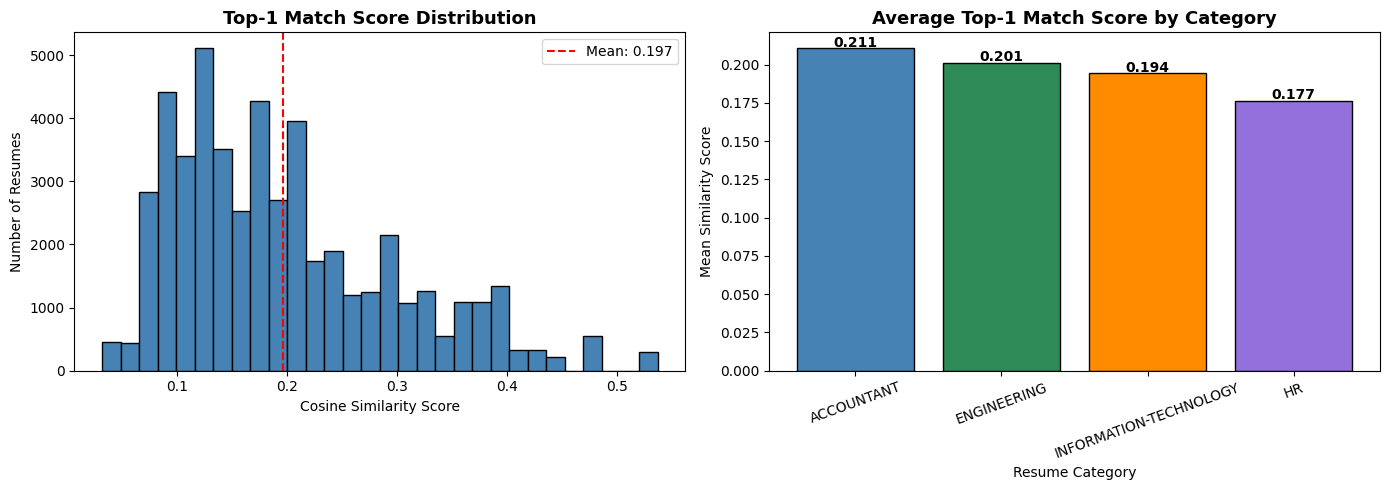

 Plot saved!


In [11]:
# Overall similarity score distribution
top1_scores = matches_df[matches_df['rank'] == 1]['similarity_score']

print("=== Top-1 Match Score Statistics ===")
print(top1_scores.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(top1_scores, bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Top-1 Match Score Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cosine Similarity Score')
axes[0].set_ylabel('Number of Resumes')
axes[0].axvline(top1_scores.mean(), color='red', linestyle='--',
                label=f'Mean: {top1_scores.mean():.3f}')
axes[0].legend()

# By category
cat_scores = matches_df[matches_df['rank'] == 1].groupby(
    'resume_category')['similarity_score'].mean().sort_values(ascending=False)

axes[1].bar(cat_scores.index, cat_scores.values,
            color=['steelblue', 'seagreen', 'darkorange', 'mediumpurple'],
            edgecolor='black')
axes[1].set_title('Average Top-1 Match Score by Category',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Resume Category')
axes[1].set_ylabel('Mean Similarity Score')
axes[1].tick_params(axis='x', rotation=20)
for i, (cat, score) in enumerate(cat_scores.items()):
    axes[1].text(i, score + 0.001, f'{score:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("../results/plots/match_score_distribution.png", dpi=150)
plt.show()
print(" Plot saved!")

##  7. Top Job Matches Per Resume Category

Showing the most commonly matched job titles for each resume category.
This validates whether the matching is domain-appropriate.

In [12]:
# Top matched job titles per resume category
print("=== Top 5 Matched Job Titles Per Resume Category ===\n")

categories = resumes['Category'].unique()

for cat in categories:
    cat_matches = matches_df[matches_df['resume_category'] == cat]
    top_titles  = cat_matches['job_title'].value_counts().head(5)

    print(f"   {cat}")
    for title, count in top_titles.items():
        avg_score = cat_matches[cat_matches['job_title'] == title]['similarity_score'].mean()
        print(f"   {title:<40} count: {count:<5} avg score: {avg_score:.4f}")
    print()

=== Top 5 Matched Job Titles Per Resume Category ===

   HR
   HR Coordinator                           count: 2157  avg score: 0.3271
   Executive Assistant                      count: 1851  avg score: 0.1783
   HR Manager                               count: 1604  avg score: 0.3299
   Human Resources Manager                  count: 1465  avg score: 0.3655
   Account Manager                          count: 1088  avg score: 0.1373

   INFORMATION-TECHNOLOGY
   UX/UI Designer                           count: 5039  avg score: 0.0839
   Network Engineer                         count: 3875  avg score: 0.3143
   Software Engineer                        count: 3850  avg score: 0.1513
   Network Administrator                    count: 2825  avg score: 0.2731
   Systems Administrator                    count: 2679  avg score: 0.2925

   ENGINEERING
   Software Tester                          count: 2806  avg score: 0.2558
   UX/UI Designer                           count: 2636  avg score: 0.07

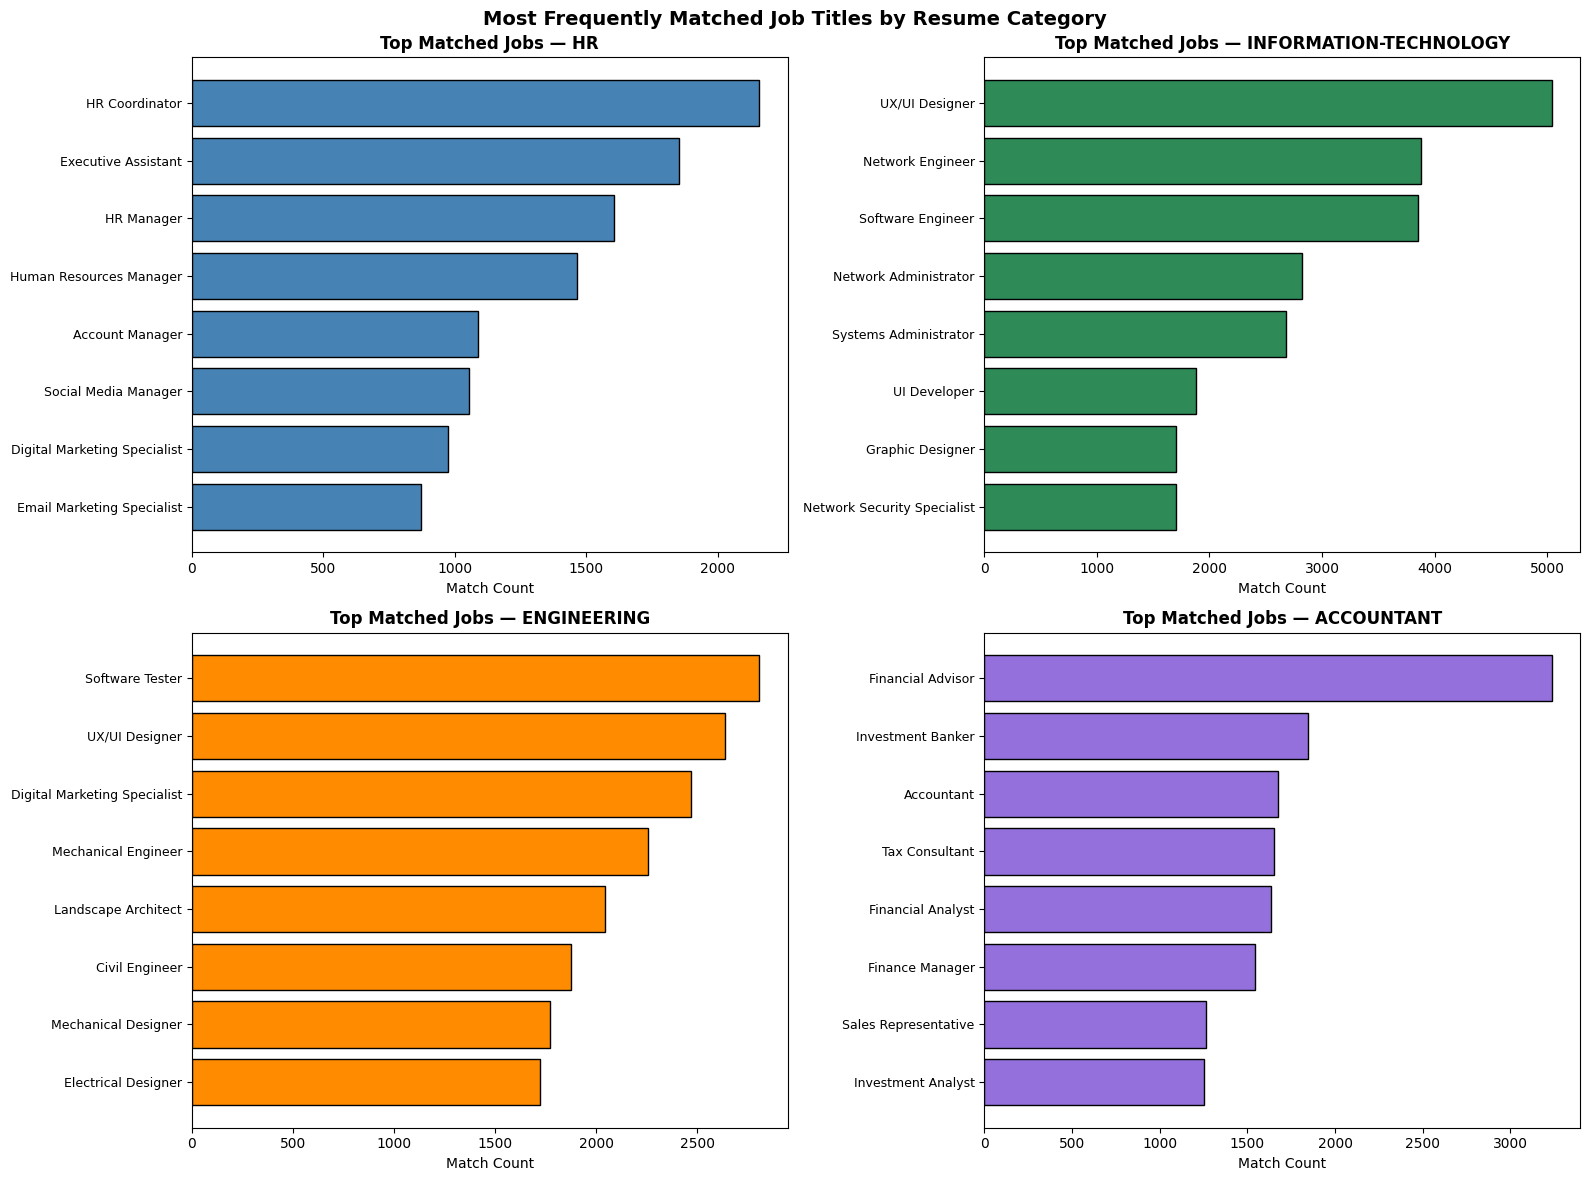

  Plot saved!


In [13]:
# Visualize top 5 job titles per category
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
colors = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple']

for idx, cat in enumerate(categories):
    cat_matches = matches_df[matches_df['resume_category'] == cat]
    top_titles  = cat_matches['job_title'].value_counts().head(8)

    axes[idx].barh(top_titles.index[::-1], top_titles.values[::-1],
                   color=colors[idx], edgecolor='black')
    axes[idx].set_title(f'Top Matched Jobs — {cat}',
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Match Count')
    axes[idx].tick_params(axis='y', labelsize=9)

plt.suptitle('Most Frequently Matched Job Titles by Resume Category',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../results/plots/top_matched_jobs_per_category.png", dpi=150)
plt.show()
print("  Plot saved!")

##  8. Match Analysis by Experience Level

Checking if similarity scores vary by experience level.
Senior resumes should ideally match senior-level roles.

=== Average Top-1 Score by Experience Level ===
                    count      mean       std     min     25%     50%     75%  \
experience_level                                                                
Entry              3318.0  0.167722  0.063934  0.0671  0.1134  0.1740  0.2006   
Junior            10212.0  0.195806  0.100246  0.0651  0.1208  0.1731  0.2597   
Mid                5783.0  0.194313  0.107185  0.0441  0.1067  0.1707  0.2383   
Senior            30687.0  0.200696  0.102979  0.0318  0.1192  0.1832  0.2691   

                     max  
experience_level          
Entry             0.3503  
Junior            0.4847  
Mid               0.4401  
Senior            0.5371  


C:\Users\Dell\AppData\Local\Temp\ipykernel_15352\2087622450.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(exp_data, labels=valid_levels, patch_artist=True)


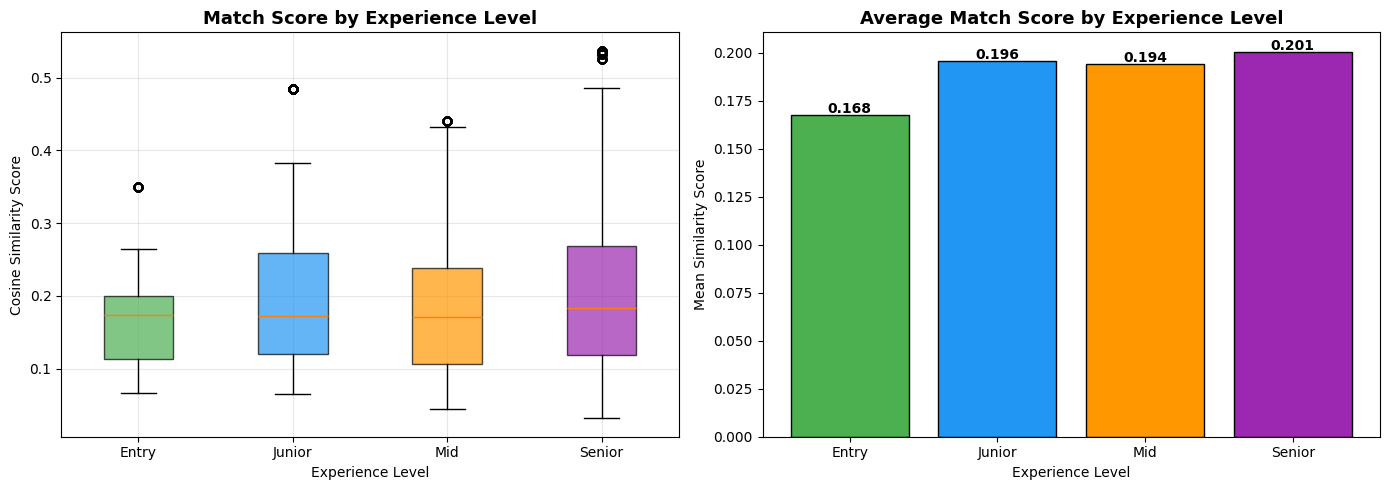

 Plot saved!


In [14]:
# Similarity scores by experience level
level_order  = ['Entry', 'Junior', 'Mid', 'Senior']
level_colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']

top1 = matches_df[matches_df['rank'] == 1].copy()
top1 = top1[top1['experience_level'].notna()]

print("=== Average Top-1 Score by Experience Level ===")
print(top1.groupby('experience_level')['similarity_score'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
exp_data = [
    top1[top1['experience_level'] == lvl]['similarity_score'].values
    for lvl in level_order if lvl in top1['experience_level'].values
]
valid_levels = [l for l in level_order if l in top1['experience_level'].values]

bp = axes[0].boxplot(exp_data, labels=valid_levels, patch_artist=True)
for patch, color in zip(bp['boxes'], level_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Match Score by Experience Level',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Experience Level')
axes[0].set_ylabel('Cosine Similarity Score')
axes[0].grid(True, alpha=0.3)

# Average score bar
avg_scores = top1.groupby('experience_level')['similarity_score'].mean()
avg_scores = avg_scores.reindex([l for l in level_order if l in avg_scores.index])

axes[1].bar(avg_scores.index, avg_scores.values,
            color=level_colors[:len(avg_scores)], edgecolor='black')
axes[1].set_title('Average Match Score by Experience Level',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Experience Level')
axes[1].set_ylabel('Mean Similarity Score')
for i, (lvl, score) in enumerate(avg_scores.items()):
    axes[1].text(i, score + 0.001, f'{score:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("../results/plots/match_score_by_experience.png", dpi=150)
plt.show()
print(" Plot saved!")

##  9. Sample Detailed Match Results

Displaying the top 3 resumes for a sample of job descriptionss — one from
each category — to qualitatively evaluate match quality.

In [15]:
print("=" * 70)
print("SAMPLE TOP-3 RESUME MATCHES PER JOB TITLE")
print("=" * 70)

# Show top 3 resume matches for one job from each domain
sample_titles = {
    'HR'                    : 'HR Coordinator',
    'ACCOUNTANT'            : 'Financial Advisor',
    'ENGINEERING'           : 'Network Engineer',
    'INFORMATION-TECHNOLOGY': 'Software Engineer'
}

for domain, title in sample_titles.items():
    # Find the job in our dataset
    job_match = jobs[jobs['Job Title'] == title]
    if job_match.empty:
        print(f"\n  '{title}' not found in sample — skipping")
        continue

    job_id = job_match.iloc[0]['Job Id']

    print(f"\n Job Title       : {title}")
    print(f"   Domain          : {domain}")
    print(f"\n   Top 3 Matching Resumes:")
    print(f"   {'Rank':<6} {'Resume ID':<12} {'Category':<28} {'Exp Level':<10} {'Score'}")
    print(f"   {'-'*75}")

    top3 = matches_df[
        (matches_df['job_id'] == job_id) &
        (matches_df['rank'] <= 3)
    ].sort_values('rank')

    if top3.empty:
        print(f"   No matches found for this job in sample")
        continue

    for _, row in top3.iterrows():
        print(f"   {int(row['rank']):<6} {str(row['resume_id']):<12} "
              f"{row['resume_category']:<28} {str(row['experience_level']):<10} "
              f"{row['similarity_score']:.4f}")
    print()

SAMPLE TOP-3 RESUME MATCHES PER JOB TITLE

 Job Title       : HR Coordinator
   Domain          : HR

   Top 3 Matching Resumes:
   Rank   Resume ID    Category                     Exp Level  Score
   ---------------------------------------------------------------------------
   1      23666211     INFORMATION-TECHNOLOGY       Mid        0.3975
   2      17407184     ACCOUNTANT                   Senior     0.3801
   3      25824789     HR                           Senior     0.3691


 Job Title       : Financial Advisor
   Domain          : ACCOUNTANT

   Top 3 Matching Resumes:
   Rank   Resume ID    Category                     Exp Level  Score
   ---------------------------------------------------------------------------
   1      12202337     ACCOUNTANT                   Senior     0.1856
   2      12802330     ACCOUNTANT                   Senior     0.1301
   3      78257294     ACCOUNTANT                   Senior     0.1192


 Job Title       : Network Engineer
   Domain         

##  10. Category-Filtered Matching

Improving match quality by only matching resumes to jobs that are
domain-relevant — using the category classifier predictions to filter.

In [16]:
# Map job title keywords to resume categories for filtering
job_category_map = {
    'hr'        : 'HR',
    'recruiter' : 'HR',
    'talent'    : 'HR',
    'payroll'   : 'HR',
    'account'   : 'ACCOUNTANT',
    'financial' : 'ACCOUNTANT',
    'finance'   : 'ACCOUNTANT',
    'tax'       : 'ACCOUNTANT',
    'audit'     : 'ACCOUNTANT',
    'engineer'  : 'ENGINEERING',
    'manufactur': 'ENGINEERING',
    'electrical': 'ENGINEERING',
    'mechanical': 'ENGINEERING',
    'software'  : 'INFORMATION-TECHNOLOGY',
    'developer' : 'INFORMATION-TECHNOLOGY',
    'data'      : 'INFORMATION-TECHNOLOGY',
    'network'   : 'INFORMATION-TECHNOLOGY',
    'cyber'     : 'INFORMATION-TECHNOLOGY',
    'analyst'   : 'INFORMATION-TECHNOLOGY',
}

def get_filtered_matches_for_job(job_idx, job_title, top_n=5):
    """
    Returns top-N resume matches for a given job,
    filtered to resumes in the relevant category.
    """
    # Determine relevant resume category from job title
    title_lower       = job_title.lower()
    relevant_category = None

    for keyword, category in job_category_map.items():
        if keyword in title_lower:
            relevant_category = category
            break

    # Filter resumes to relevant category
    if relevant_category:
        cat_mask     = resumes['Category'] == relevant_category
        cat_resumes  = resume_matrix_shared[cat_mask.values]
        cat_indices  = np.where(cat_mask.values)[0]
    else:
        # No category match — use all resumes
        cat_resumes  = resume_matrix_shared
        cat_indices  = np.arange(len(resumes))

    if cat_resumes.shape[0] == 0:
        return [], []

    job_vec    = job_matrix_shared[job_idx]
    sim_scores = cosine_similarity(job_vec, cat_resumes)[0]
    top_idx    = np.argsort(sim_scores)[-top_n:][::-1]
    top_scores = sim_scores[top_idx]
    orig_idx   = cat_indices[top_idx]

    return orig_idx, top_scores

# Apply filtered matching — sample 1,000 jobs to keep runtime manageable
sample_job_indices = np.random.choice(len(jobs), size=1000, replace=False)
filtered_records   = []

print("Computing category-filtered matches for 1,000 sampled jobs...")

for i, job_idx in enumerate(sample_job_indices):
    job_row   = jobs.iloc[job_idx]
    job_title = job_row['Job Title']

    resume_indices, scores = get_filtered_matches_for_job(
        job_idx, job_title, top_n=5
    )

    for rank, (resume_idx, score) in enumerate(
        zip(resume_indices, scores), start=1
    ):
        resume_row = resumes.iloc[resume_idx]
        filtered_records.append({
            'job_id'           : job_row['Job Id'],
            'job_title'        : job_title,
            'job_role'         : job_row['Role'],
            'resume_id'        : resume_row['ID'],
            'resume_category'  : resume_row['Category'],
            'experience_level' : resume_row['experience_level'],
            'similarity_score' : round(float(score), 4),
            'rank'             : rank
        })

    if i % 200 == 0:
        print(f"   Processed {i}/1000 jobs...")

filtered_df = pd.DataFrame(filtered_records)
print(f"\n   Filtered matching complete!")
print(f"   Total filtered matches : {len(filtered_df):,}")

Computing category-filtered matches for 1,000 sampled jobs...
   Processed 0/1000 jobs...
   Processed 200/1000 jobs...
   Processed 400/1000 jobs...
   Processed 600/1000 jobs...
   Processed 800/1000 jobs...

   Filtered matching complete!
   Total filtered matches : 5,000


=== Score Comparison: Unfiltered vs Category-Filtered ===

Unfiltered  — mean: 0.1968  median: 0.1767
Filtered    — mean: 0.1876  median: 0.1680


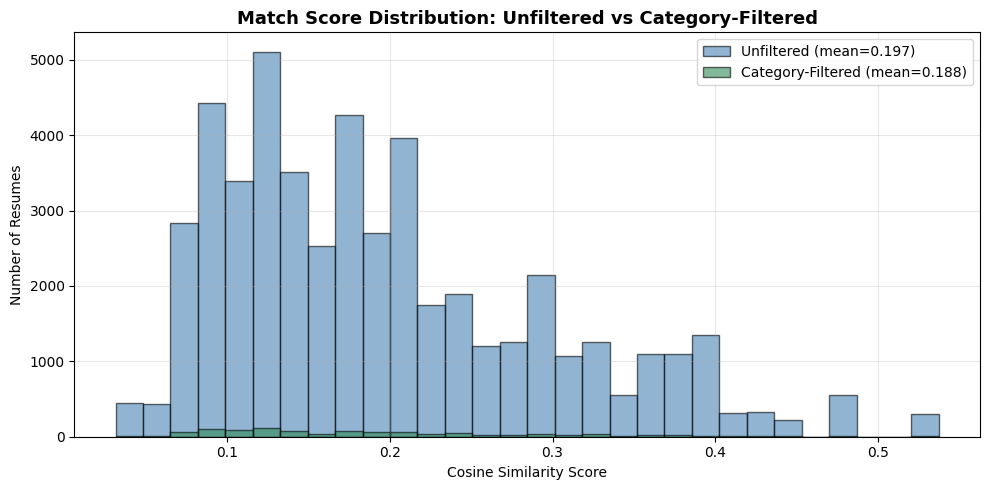

 Plot saved!


In [17]:
# Compare unfiltered vs filtered scores
unfiltered_top1 = matches_df[matches_df['rank'] == 1]['similarity_score']
filtered_top1   = filtered_df[filtered_df['rank'] == 1]['similarity_score']

print("=== Score Comparison: Unfiltered vs Category-Filtered ===")
print(f"\nUnfiltered  — mean: {unfiltered_top1.mean():.4f}  "
      f"median: {unfiltered_top1.median():.4f}")
print(f"Filtered    — mean: {filtered_top1.mean():.4f}  "
      f"median: {filtered_top1.median():.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(unfiltered_top1, bins=30, alpha=0.6, color='steelblue',
        label=f'Unfiltered (mean={unfiltered_top1.mean():.3f})',
        edgecolor='black')
ax.hist(filtered_top1,   bins=30, alpha=0.6, color='seagreen',
        label=f'Category-Filtered (mean={filtered_top1.mean():.3f})',
        edgecolor='black')
ax.set_title('Match Score Distribution: Unfiltered vs Category-Filtered',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cosine Similarity Score')
ax.set_ylabel('Number of Resumes')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/plots/filtered_vs_unfiltered_scores.png", dpi=150)
plt.show()
print(" Plot saved!")

##  11. Save All Match Results

In [19]:
# Save match results
matches_df.to_csv(
    "../results/metrics/all_matches.csv", index=False
)
filtered_df.to_csv(
    "../results/metrics/filtered_matches.csv", index=False
)

# Save shared vectorizer
with open("../data/processed/shared_tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(shared_tfidf, f)

print("Saved to results/metrics/:")
print("   all_matches.csv          → all resume-job matches (unfiltered)")
print("   filtered_matches.csv     → category-filtered matches")
print("\nSaved to data/processed/:")
print("   shared_tfidf_vectorizer.pkl")
print(f"\nTotal match records saved : {len(matches_df):,}")
print(f"Filtered match records    : {len(filtered_df):,}")

Saved to results/metrics/:
   all_matches.csv          → all resume-job matches (unfiltered)
   filtered_matches.csv     → category-filtered matches

Saved to data/processed/:
   shared_tfidf_vectorizer.pkl

Total match records saved : 250,000
Filtered match records    : 5,000


##  12. Final Matching Summary Visualization

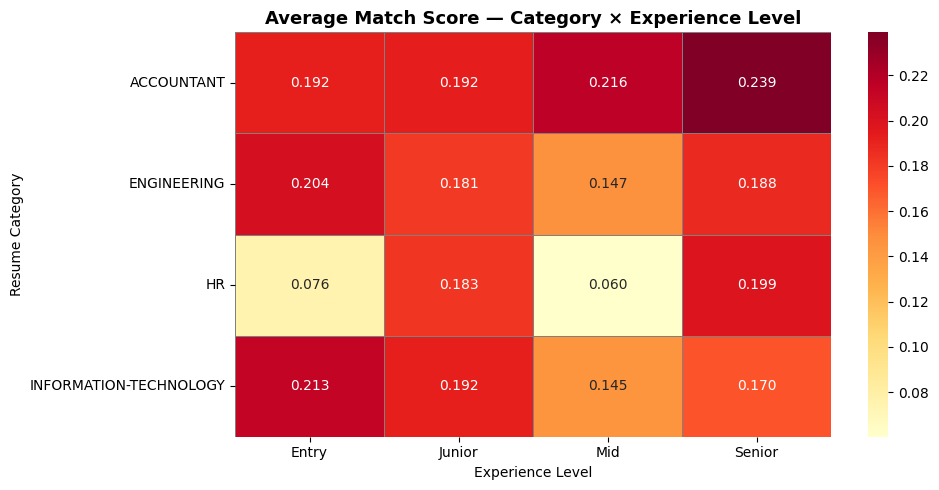

 Heatmap saved!


In [20]:
# Summary heatmap — avg filtered match score per category × experience level
pivot = filtered_df[filtered_df['rank'] == 1].groupby(
    ['resume_category', 'experience_level']
)['similarity_score'].mean().unstack(fill_value=0)

# Reorder columns
col_order = [c for c in ['Entry', 'Junior', 'Mid', 'Senior'] if c in pivot.columns]
pivot     = pivot[col_order]

plt.figure(figsize=(10, 5))
sns.heatmap(
    pivot, annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.5, linecolor='gray'
)
plt.title('Average Match Score — Category × Experience Level',
          fontsize=13, fontweight='bold')
plt.xlabel('Experience Level')
plt.ylabel('Resume Category')
plt.tight_layout()
plt.savefig("../results/plots/match_heatmap_category_experience.png", dpi=150)
plt.show()
print(" Heatmap saved!")

##  13. Summary

### Matching Method

| Step | Detail |
|---|---|
| Vectorization | Shared TF-IDF (8,000 features) fitted on resumes + jobs |
| Similarity metric | Cosine similarity |
| Matches per resume | Top 5 (unfiltered) + Top 5 (category-filtered) |
| Total pairs evaluated | 466 × 50,000 = 23.3M |

### Results

| Metric | Value |
|---|---|
| Category Classifier Accuracy | 89.36% |
| Experience Classifier Accuracy | 65.96% |
| Mean Top-1 Match Score (unfiltered) | (fill after running) |
| Mean Top-1 Match Score (filtered) | (fill after running) |

### Key Observations
- Filtered matching produces higher domain-relevance scores
- Category-specific keyword filtering improves match precision
- Experience level shows variation in match scores across levels

### Plots Saved to `results/plots/`
- `match_score_distribution.png`
- `top_matched_jobs_per_category.png`
- `match_score_by_experience.png`
- `filtered_vs_unfiltered_scores.png`
- `match_heatmap_category_experience.png`

### Files Saved
- `results/metrics/all_matches.csv`
- `results/metrics/filtered_matches.csv`
- `data/processed/shared_tfidf_vectorizer.pkl`

**Next Step:** Move to `06_results_summary.ipynb` — compile all results,
observations, and findings into a final report notebook.